# 07 Threshold Tuning and Credit Risk Scorecard

## Loan Default Prediction and Credit Risk Scorecard

This notebook converts model scores into business-friendly risk bands. It evaluates classification thresholds, manual review volume, default capture, and risk segmentation logic for underwriting and portfolio monitoring.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [3]:
scores = pd.read_csv("../data/outputs/tree_model_score_output.csv")

scores.shape

(342392, 39)

In [4]:
scores.head()

,loan_amnt,term_months,int_rate,installment,grade,sub_grade,grade_risk_numeric,emp_length_years,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,issue_year,issue_month,credit_history_months,loan_income_ratio,installment_income_ratio,high_dti_flag,high_revol_util_flag,recent_inquiry_flag,long_term_flag,income_band,dti_band,credit_history_band,actual_default,predicted_pd_tree_model,predicted_default_050,model_name
0,10000.0,36,10.49,324.98,B,B3,2,10.0,MORTGAGE,62000.0,Not Verified,debt_consolidation,9.50,0.0,0.0,16.0,1.0,8056.0,26.2,53.0,Individual,1.0,1.0,2016,10,289.0,0.161290,0.062899,0,0,0,0,Middle Income,Low DTI,Long Credit History,0,0.334686,0,LightGBM
1,4000.0,36,12.69,134.18,C,C2,3,10.0,MORTGAGE,102000.0,Not Verified,home_improvement,18.24,0.0,0.0,8.0,0.0,7132.0,52.4,10.0,Individual,2.0,0.0,2015,3,83.0,0.039216,0.015786,0,0,0,0,Upper Middle Income,Moderate DTI,Moderate Credit History,0,0.301948,0,LightGBM
2,22400.0,60,18.99,580.95,D,D3,4,10.0,MORTGAGE,70000.0,Not Verified,credit_card,25.72,0.0,1.0,7.0,1.0,11386.0,40.4,22.0,Individual,3.0,1.0,2016,12,279.0,0.320000,0.099591,0,0,0,1,Middle Income,High DTI,Long Credit History,0,0.639001,1,LightGBM
3,10000.0,36,10.99,327.34,B,B2,2,0.0,RENT,70000.0,Not Verified,debt_consolidation,17.59,0.0,1.0,13.0,0.0,10130.0,39.2,17.0,Individual,0.0,0.0,2014,1,100.0,0.142857,0.056115,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.278931,0,LightGBM
4,5000.0,36,9.17,159.40,B,B2,2,0.0,OWN,62000.0,Source Verified,debt_consolidation,15.18,0.0,0.0,6.0,0.0,5129.0,68.4,12.0,Individual,1.0,0.0,2016,1,101.0,0.080645,0.030852,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.261981,0,LightGBM


In [5]:
y_true = scores["actual_default"]
y_prob = scores["predicted_pd_tree_model"]

print("Observed default rate:", round(y_true.mean() * 100, 2))
print("Average raw model score:", round(y_prob.mean() * 100, 2))

Observed default rate: 21.24
Average raw model score: 45.29


## Probability Interpretation Note

The previous calibration analysis showed that the raw LightGBM predicted probabilities overestimate observed default rates. Therefore, in this notebook the model output is treated primarily as a risk-ranking score for segmentation and review prioritization.

Before production use as a true probability of default, the model would require probability calibration and validation on current internal lending data.

In [6]:
def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total = len(y_true)
    review_count = tp + fp
    review_rate = review_count / total
    
    total_defaults = y_true.sum()
    default_capture_rate = tp / total_defaults
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
        "manual_review_count": review_count,
        "manual_review_rate": review_rate,
        "default_capture_rate": default_capture_rate
    }

In [7]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = pd.DataFrame([
    evaluate_threshold(y_true, y_prob, threshold)
    for threshold in thresholds
])

percentage_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "manual_review_rate",
    "default_capture_rate"
]

threshold_display = threshold_results.copy()

for col in percentage_cols:
    threshold_display[col] = (threshold_display[col] * 100).round(2)

threshold_display

,threshold,accuracy,precision,recall,f1_score,true_positives,false_positives,true_negatives,false_negatives,manual_review_count,manual_review_rate,default_capture_rate
0,0.30,43.00,26.15,92.30,40.75,67105,189550,80135,5602,256655,74.96,92.30
1,0.35,49.05,27.85,88.01,42.32,63988,165736,103949,8719,229724,67.09,88.01
2,0.40,54.94,29.76,82.52,43.75,59999,141587,128098,12708,201586,58.88,82.52
3,0.45,60.66,32.02,75.94,45.05,55214,117203,152482,17493,172417,50.36,75.94
4,0.50,65.94,34.60,67.88,45.84,49357,93275,176410,23350,142632,41.66,67.88
5,0.55,70.42,37.46,58.71,45.74,42685,71259,198426,30022,113944,33.28,58.71
6,0.60,74.11,40.86,48.96,44.55,35599,51526,218159,37108,87125,25.45,48.96
7,0.65,76.79,44.64,38.77,41.50,28185,34951,234734,44522,63136,18.44,38.77
8,0.70,78.51,48.96,28.46,35.99,20691,21569,248116,52016,42260,12.34,28.46


In [8]:
threshold_results.to_csv("../data/outputs/threshold_tuning_results.csv", index=False)
threshold_display.to_csv("../data/outputs/threshold_tuning_results_display.csv", index=False)

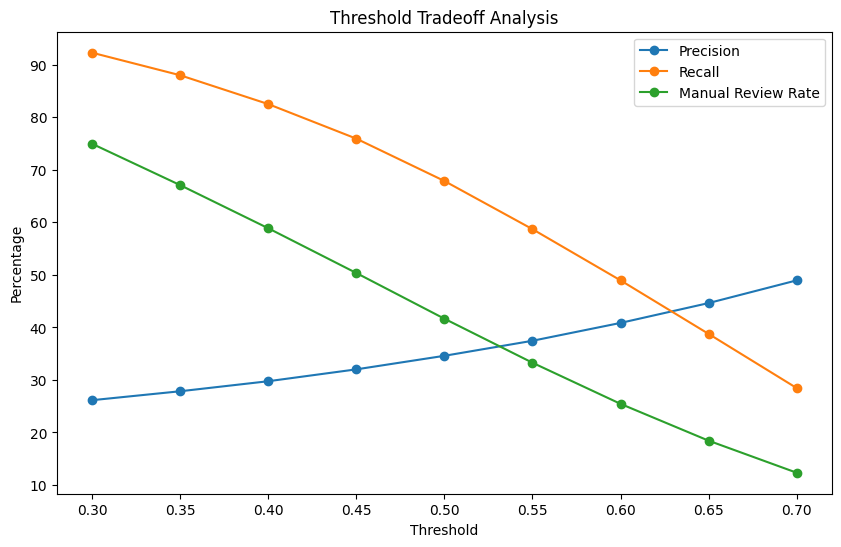

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_display["threshold"], threshold_display["precision"], marker="o", label="Precision")
plt.plot(threshold_display["threshold"], threshold_display["recall"], marker="o", label="Recall")
plt.plot(threshold_display["threshold"], threshold_display["manual_review_rate"], marker="o", label="Manual Review Rate")
plt.title("Threshold Tradeoff Analysis")
plt.xlabel("Threshold")
plt.ylabel("Percentage")
plt.legend()
plt.show()

## Recommended Review Threshold

For this portfolio project, a threshold of 0.50 is used as the initial manual review threshold because it captures a large share of actual defaults while maintaining a manageable precision level for a screening model.

In a real lending environment, this threshold would be selected based on operational review capacity, cost of false positives, cost of false negatives, expected credit loss, and regulatory/model risk governance.

In [10]:
scorecard_df = scores.copy()

scorecard_df["score_percentile"] = scorecard_df["predicted_pd_tree_model"].rank(pct=True)

def assign_risk_band_by_percentile(percentile):
    if percentile < 0.50:
        return "Low Risk"
    elif percentile < 0.75:
        return "Medium Risk"
    elif percentile < 0.90:
        return "High Risk"
    else:
        return "Critical Risk"

scorecard_df["risk_band"] = scorecard_df["score_percentile"].apply(assign_risk_band_by_percentile)

scorecard_df["risk_band"].value_counts(normalize=True).mul(100).round(2)

risk_band
Low Risk         50.0
Medium Risk      25.0
High Risk        15.0
Critical Risk    10.0
Name: proportion, dtype: float64

## Risk Band Design

Because the raw model probabilities are not fully calibrated, risk bands are created using score percentiles instead of fixed probability ranges.

This approach is appropriate for portfolio segmentation because it ranks borrowers relative to the scored population and creates stable business segments for monitoring and manual review.

In [11]:
risk_band_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

risk_band_summary = (
    scorecard_df.groupby("risk_band")
    .agg(
        loan_count=("actual_default", "count"),
        default_count=("actual_default", "sum"),
        avg_model_score=("predicted_pd_tree_model", "mean"),
        min_model_score=("predicted_pd_tree_model", "min"),
        max_model_score=("predicted_pd_tree_model", "max"),
        observed_default_rate=("actual_default", "mean")
    )
    .reset_index()
)

risk_band_summary["risk_band"] = pd.Categorical(
    risk_band_summary["risk_band"],
    categories=risk_band_order,
    ordered=True
)

risk_band_summary = risk_band_summary.sort_values("risk_band")

risk_band_summary["portfolio_share_pct"] = (
    risk_band_summary["loan_count"] / len(scorecard_df) * 100
).round(2)

risk_band_summary["observed_default_rate_pct"] = (
    risk_band_summary["observed_default_rate"] * 100
).round(2)

risk_band_summary["avg_model_score_pct"] = (
    risk_band_summary["avg_model_score"] * 100
).round(2)

risk_band_summary["min_model_score_pct"] = (
    risk_band_summary["min_model_score"] * 100
).round(2)

risk_band_summary["max_model_score_pct"] = (
    risk_band_summary["max_model_score"] * 100
).round(2)

risk_band_summary

,risk_band,loan_count,default_count,avg_model_score,min_model_score,max_model_score,observed_default_rate,portfolio_share_pct,observed_default_rate_pct,avg_model_score_pct,min_model_score_pct,max_model_score_pct
2,Low Risk,171195,17703,0.289129,0.031761,0.452007,0.103408,50.0,10.34,28.91,3.18,45.20
3,Medium Risk,85598,19841,0.525524,0.452010,0.602947,0.231793,25.0,23.18,52.55,45.20,60.29
1,High Risk,51359,17676,0.658830,0.602949,0.720953,0.344166,15.0,34.42,65.88,60.29,72.10
0,Critical Risk,34240,17487,0.781616,0.720954,0.924914,0.510718,10.0,51.07,78.16,72.10,92.49


In [12]:
action_map = {
    "Low Risk": "Standard approval path; routine monitoring",
    "Medium Risk": "Standard review; monitor risk indicators",
    "High Risk": "Manual underwriting review recommended",
    "Critical Risk": "Senior review, additional documentation, or decline consideration"
}

monitoring_map = {
    "Low Risk": "Monthly portfolio monitoring",
    "Medium Risk": "Monthly segment monitoring",
    "High Risk": "Weekly/monthly review of default trends",
    "Critical Risk": "Close monitoring and policy review"
}

risk_band_summary["recommended_action"] = risk_band_summary["risk_band"].astype(str).map(action_map)
risk_band_summary["monitoring_requirement"] = risk_band_summary["risk_band"].astype(str).map(monitoring_map)

risk_band_summary

,risk_band,loan_count,default_count,avg_model_score,min_model_score,max_model_score,observed_default_rate,portfolio_share_pct,observed_default_rate_pct,avg_model_score_pct,min_model_score_pct,max_model_score_pct,recommended_action,monitoring_requirement
2,Low Risk,171195,17703,0.289129,0.031761,0.452007,0.103408,50.0,10.34,28.91,3.18,45.20,Standard approval path; routine monitoring,Monthly portfolio monitoring
3,Medium Risk,85598,19841,0.525524,0.452010,0.602947,0.231793,25.0,23.18,52.55,45.20,60.29,Standard review; monitor risk indicators,Monthly segment monitoring
1,High Risk,51359,17676,0.658830,0.602949,0.720953,0.344166,15.0,34.42,65.88,60.29,72.10,Manual underwriting review recommended,Weekly/monthly review of default trends
0,Critical Risk,34240,17487,0.781616,0.720954,0.924914,0.510718,10.0,51.07,78.16,72.10,92.49,"Senior review, additional documentation, or de...",Close monitoring and policy review


In [13]:
risk_band_summary.to_csv("../data/outputs/risk_band_summary.csv", index=False)

scorecard_df.to_csv("../data/outputs/final_scorecard_output.csv", index=False)

print("Risk band summary and final scorecard output saved.")

Risk band summary and final scorecard output saved.


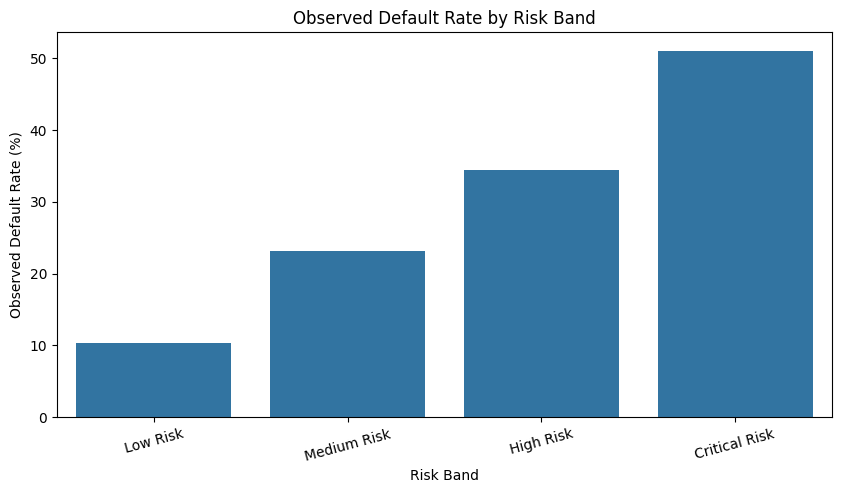

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=risk_band_summary, x="risk_band", y="observed_default_rate_pct")
plt.title("Observed Default Rate by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Observed Default Rate (%)")
plt.xticks(rotation=15)
plt.show()

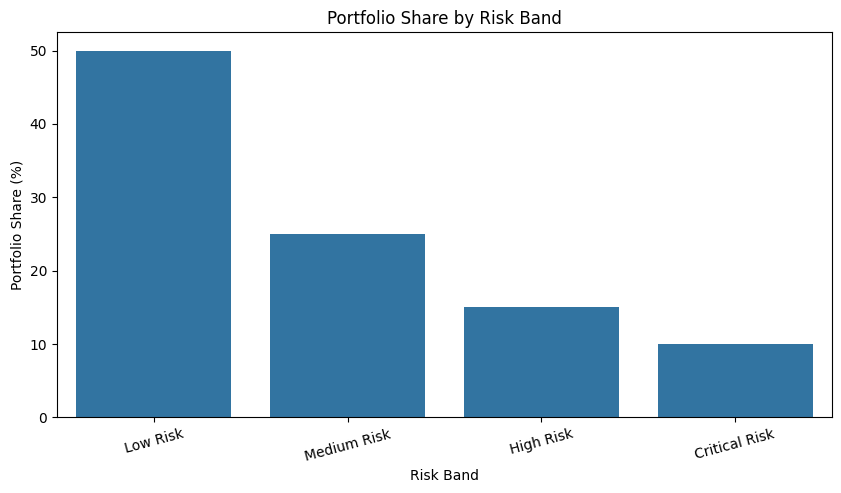

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=risk_band_summary, x="risk_band", y="portfolio_share_pct")
plt.title("Portfolio Share by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Portfolio Share (%)")
plt.xticks(rotation=15)
plt.show()

In [16]:
business_scorecard = risk_band_summary[
    [
        "risk_band",
        "portfolio_share_pct",
        "min_model_score_pct",
        "max_model_score_pct",
        "observed_default_rate_pct",
        "recommended_action",
        "monitoring_requirement"
    ]
].copy()

business_scorecard

,risk_band,portfolio_share_pct,min_model_score_pct,max_model_score_pct,observed_default_rate_pct,recommended_action,monitoring_requirement
2,Low Risk,50.0,3.18,45.20,10.34,Standard approval path; routine monitoring,Monthly portfolio monitoring
3,Medium Risk,25.0,45.20,60.29,23.18,Standard review; monitor risk indicators,Monthly segment monitoring
1,High Risk,15.0,60.29,72.10,34.42,Manual underwriting review recommended,Weekly/monthly review of default trends
0,Critical Risk,10.0,72.10,92.49,51.07,"Senior review, additional documentation, or de...",Close monitoring and policy review


In [17]:
business_scorecard.to_csv("../data/outputs/business_scorecard.csv", index=False)

# Credit Risk Scorecard Interpretation

The scorecard converts model outputs into practical risk bands that can support underwriting and portfolio monitoring.

Because the model's raw probabilities are not fully calibrated, the bands are based on relative score percentiles rather than direct probability cutoffs.

The highest-risk band should not be used for automatic rejection. Instead, it should trigger manual review, additional documentation checks, or senior underwriting review.

The scorecard is designed as a decision-support tool, not a fully automated lending decision engine.

# Threshold Tuning and Scorecard Summary

## Key Actions Completed

- Evaluated multiple model score thresholds.
- Compared precision, recall, F1-score, manual review rate, and default capture rate.
- Selected an initial review threshold for business interpretation.
- Created percentile-based borrower risk bands.
- Built Low, Medium, High, and Critical Risk segments.
- Added recommended underwriting actions and monitoring requirements.
- Saved final scorecard outputs for dashboarding and reporting.

## Next Step

The next notebook will create business recommendations and prepare dashboard-ready outputs.